# NeuroScribe — EDA & Preprocessing
**Dataset:** CHB-MIT Scalp EEG Database  
**Goal:** Explore the dataset, visualize key statistics, and run the full preprocessing pipeline.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

# ── Make src/ importable from notebooks/ ───────────────────────────────────
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.signal import welch, spectrogram
import mne
mne.set_log_level('WARNING')

# ── NeuroScribe src imports ─────────────────────────────────────────────────
from src.data.loader import (
    parse_summary_file,
    build_patient_manifest,
    load_recording,
    dataset_stats,
)
from src.data.preprocessor import (
    bandpass_filter,
    notch_filter,
    apply_filters,
    create_windows,
    zscore_normalize,
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR    = '../data/chb-mit'
FS          = 256
WINDOW_SEC  = 4
OVERLAP     = 0.5
WINDOW_SAMP = WINDOW_SEC * FS
STEP_SAMP   = int(WINDOW_SAMP * (1 - OVERLAP))

print('Setup complete.')

Setup complete.


---
## 1. Dataset Overview

In [2]:
# ── Scan all patient directories ───────────────────────────────────────────
rows = []
patient_dirs = sorted([d for d in os.listdir(DATA_DIR) if d.startswith('chb')])

for pdir in patient_dirs:
    ppath     = os.path.join(DATA_DIR, pdir)
    summaries = [f for f in os.listdir(ppath) if 'summary' in f.lower() and f.endswith('.txt')]
    edfs      = [f for f in os.listdir(ppath) if f.endswith('.edf')]
    if not summaries: continue

    ann       = parse_summary_file(os.path.join(ppath, summaries[0]))
    sz_files  = [f for f, s in ann.items() if s]
    all_seiz  = [s for seiz in ann.values() for s in seiz]
    total_dur = sum(s.duration for s in all_seiz)

    rows.append({
        'Patient':              pdir,
        'EDF Files':            len(edfs),
        'Seizure Files':        len(sz_files),
        'Total Seizures':       len(all_seiz),
        'Seizure Duration (s)': round(total_dur, 1),
        'Avg Duration (s)':     round(total_dur / max(len(all_seiz), 1), 1),
    })

df_overview = pd.DataFrame(rows)
print(f'Patients found : {len(df_overview)}')
print(f'Total EDF files: {df_overview["EDF Files"].sum()}')
print(f'Total seizures : {df_overview["Total Seizures"].sum()}')
print(f'Total seizure duration: {df_overview["Seizure Duration (s)"].sum():.0f} s')
print()
df_overview

Seizure 2 has start but no end — skipping
Expected 2 seizures, parsed 1
Expected 2 seizures, parsed 1
Expected 2 seizures, parsed 1
Expected 3 seizures, parsed 1


Patients found : 24
Total EDF files: 686
Total seizures : 193
Total seizure duration: 17664 s



,Patient,EDF Files,Seizure Files,Total Seizures,Seizure Duration (s),Avg Duration (s)
0,chb01,42,7,7,442.0,63.1
1,chb02,36,3,3,172.0,57.3
2,chb03,38,7,7,402.0,57.4
3,chb04,42,3,4,378.0,94.5
4,chb05,39,5,5,558.0,111.6
5,chb06,18,7,10,153.0,15.3
6,chb07,19,3,3,325.0,108.3
7,chb08,20,5,5,919.0,183.8
8,chb09,19,3,3,6442.0,2147.3
9,chb10,25,7,7,447.0,63.9


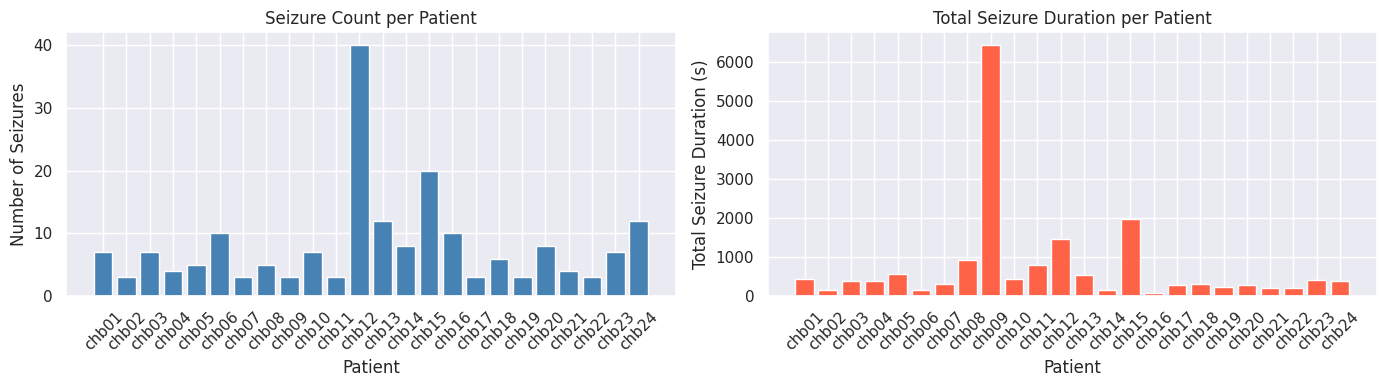

In [3]:
# ── Per-patient seizure count bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(df_overview['Patient'], df_overview['Total Seizures'], color='steelblue')
axes[0].set_xlabel('Patient'); axes[0].set_ylabel('Number of Seizures')
axes[0].set_title('Seizure Count per Patient')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(df_overview['Patient'], df_overview['Seizure Duration (s)'], color='tomato')
axes[1].set_xlabel('Patient'); axes[1].set_ylabel('Total Seizure Duration (s)')
axes[1].set_title('Total Seizure Duration per Patient')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 2. Load a Sample Recording

In [4]:
# ── Pick first patient that has a seizure EDF on disk ─────────────────────
PATIENT     = 'chb01'
PATIENT_DIR = os.path.join(DATA_DIR, PATIENT)

recordings   = build_patient_manifest(PATIENT_DIR, patient_id=1)
seizure_recs = [r for r in recordings if r.has_seizure and os.path.exists(r.edf_path)]
normal_recs  = [r for r in recordings if not r.has_seizure and os.path.exists(r.edf_path)]

print(f'Patient              : {PATIENT}')
print(f'Seizure EDFs on disk : {len(seizure_recs)}')
print(f'Normal  EDFs on disk : {len(normal_recs)}')
print(f'\nSeizure files:')
for r in seizure_recs:
    print(f'  {r.filename}  →  ' +
          ', '.join(f'{s.onset:.0f}–{s.offset:.0f}s (dur {s.duration:.0f}s)'
                    for s in r.seizures))

Patient              : chb01
Seizure EDFs on disk : 7
Normal  EDFs on disk : 35

Seizure files:
  chb01_03.edf  →  2996–3036s (dur 40s)
  chb01_04.edf  →  1467–1494s (dur 27s)
  chb01_15.edf  →  1732–1772s (dur 40s)
  chb01_16.edf  →  1015–1066s (dur 51s)
  chb01_18.edf  →  1720–1810s (dur 90s)
  chb01_21.edf  →  327–420s (dur 93s)
  chb01_26.edf  →  1862–1963s (dur 101s)


In [5]:
# ── Load first seizure EDF via src loader ─────────────────────────────────
TARGET_REC = seizure_recs[0]
TARGET_EDF = TARGET_REC.filename

recording = load_recording(TARGET_REC)

data      = recording.data
ch_names  = recording.channel_names
n_channels, n_samples = data.shape
duration_sec = n_samples / FS

# seizure_intervals as (onset, offset) tuples — keeps all downstream viz unchanged
seizure_intervals = [(s.onset, s.offset) for s in TARGET_REC.seizures]

print(f'File          : {TARGET_EDF}')
print(f'Shape         : {data.shape}  (channels × samples)')
print(f'Sample rate   : {recording.sample_rate} Hz')
print(f'Duration      : {duration_sec:.1f} s  ({duration_sec/60:.1f} min)')
print(f'Channels      : {n_channels}')
print(f'Value range   : [{data.min():.1f}, {data.max():.1f}] µV')
print(f'\nChannel names:')
for i, ch in enumerate(ch_names):
    print(f'  [{i:02d}] {ch}')

File          : chb01_03.edf
Shape         : (23, 921600)  (channels × samples)
Sample rate   : 256 Hz
Duration      : 3600.0 s  (60.0 min)
Channels      : 23
Value range   : [-721.1, 595.3] µV

Channel names:
  [00] FP1-F7
  [01] F7-T7
  [02] T7-P7
  [03] P7-O1
  [04] FP1-F3
  [05] F3-C3
  [06] C3-P3
  [07] P3-O1
  [08] FP2-F4
  [09] F4-C4
  [10] C4-P4
  [11] P4-O2
  [12] FP2-F8
  [13] F8-T8
  [14] T8-P8-0
  [15] P8-O2
  [16] FZ-CZ
  [17] CZ-PZ
  [18] P7-T7
  [19] T7-FT9
  [20] FT9-FT10
  [21] FT10-T8
  [22] T8-P8-1


In [6]:
# ── Print first 5 raw samples ──────────────────────────────────────────────
n_show = min(6, n_channels)
df_samples = pd.DataFrame(
    data[:n_show, :5].T,
    columns=ch_names[:n_show],
    index=[f't={i/FS:.4f}s' for i in range(5)]
).round(2)
print('First 5 samples (µV) — first 6 channels:')
df_samples

First 5 samples (µV) — first 6 channels:


,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3
t=0.0000s,-17.78,39.27,-3.71,8.4,-0.59,4.1
t=0.0039s,0.20,0.20,0.20,0.2,0.20,0.2
t=0.0078s,0.20,0.20,0.20,0.2,0.20,0.2
t=0.0117s,0.59,0.20,0.20,0.2,0.20,0.2
t=0.0156s,0.20,0.20,0.20,0.2,0.20,0.2


---
## 3. EDA — Signal Visualization

In [7]:
# ── Label array already built by src loader ────────────────────────────────
label_array = recording.label_array   # 0=non-seizure, 1=seizure (sample-level)

print(f'Seizure intervals : {seizure_intervals}')
print(f'Seizure samples   : {label_array.sum()} / {n_samples}  ({100*label_array.mean():.2f}%)')

Seizure intervals : [(2996.0, 3036.0)]
Seizure samples   : 10240 / 921600  (1.11%)


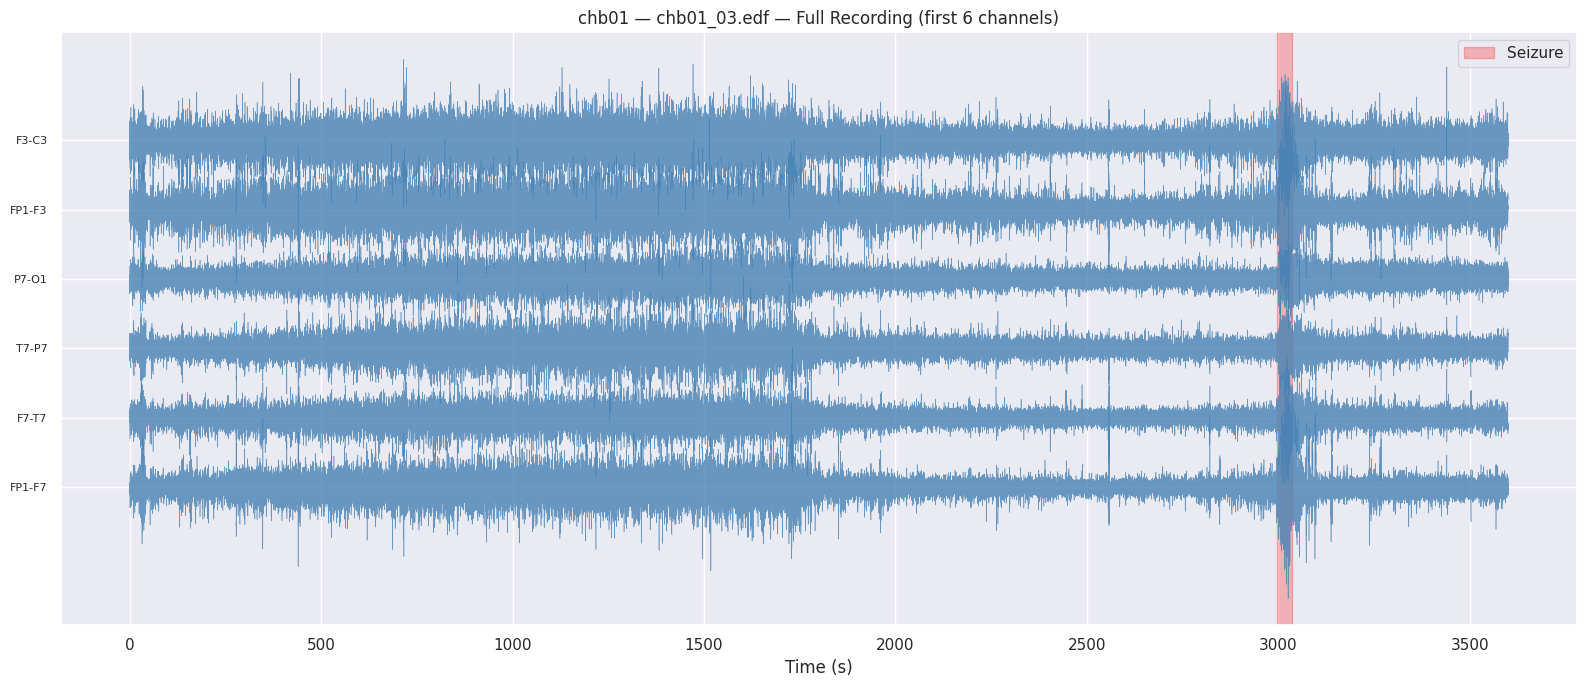

In [8]:
# ── Full recording overview with seizure shading ───────────────────────────
CH_SHOW = min(6, n_channels)
offset_scale = 300

fig, ax = plt.subplots(figsize=(16, 7))
t = np.arange(n_samples) / FS

for i in range(CH_SHOW):
    ax.plot(t, data[i] + i * offset_scale, lw=0.4, color='steelblue', alpha=0.8)

for onset, offset in seizure_intervals:
    ax.axvspan(onset, offset, alpha=0.25, color='red', label='Seizure')

ax.set_yticks([i * offset_scale for i in range(CH_SHOW)])
ax.set_yticklabels(ch_names[:CH_SHOW], fontsize=8)
ax.set_xlabel('Time (s)')
ax.set_title(f'{PATIENT} — {TARGET_EDF} — Full Recording (first {CH_SHOW} channels)')
handles, labels_ = ax.get_legend_handles_labels()
if handles: ax.legend(handles[:1], labels_[:1], loc='upper right')
plt.tight_layout(); plt.show()

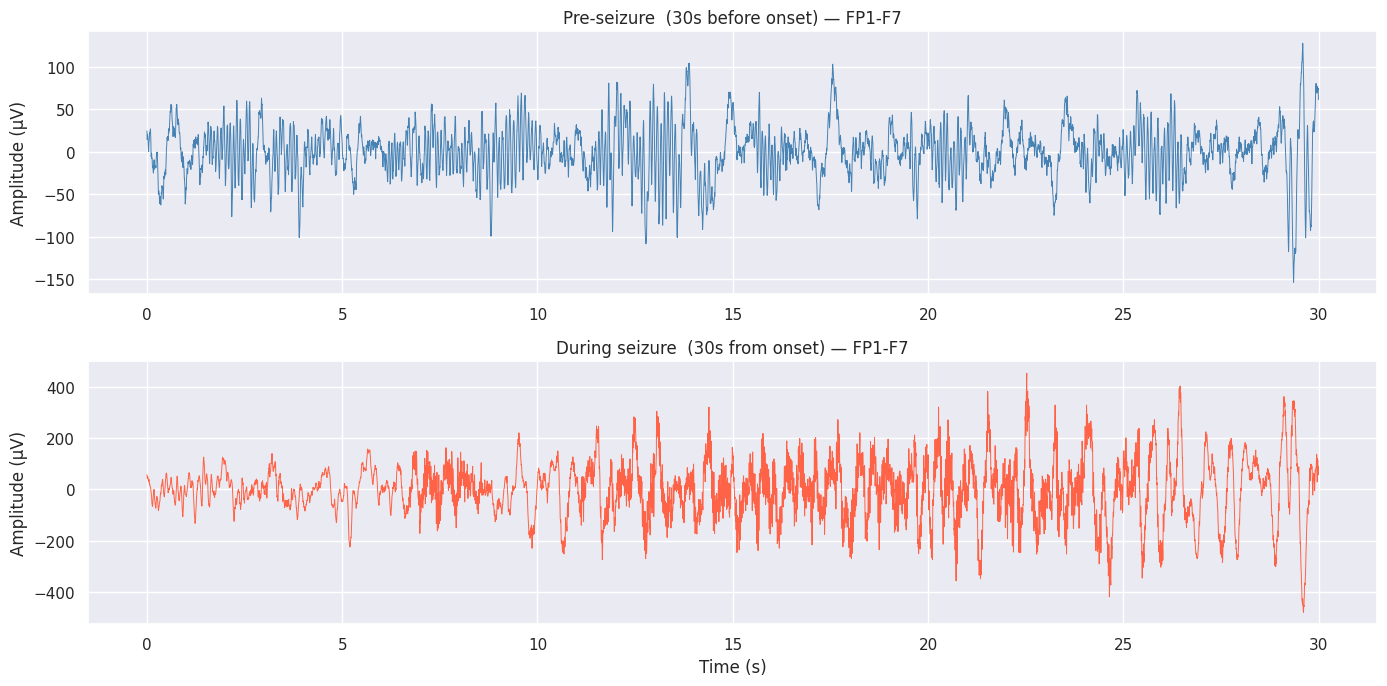

In [9]:
# ── Zoom: 30s before vs 30s during seizure ─────────────────────────────────
onset_sec  = seizure_intervals[0][0]
offset_sec = seizure_intervals[0][1]
pad        = 30

pre_start  = max(0, int((onset_sec - pad) * FS))
pre_end    = int(onset_sec * FS)
sz_start   = int(onset_sec * FS)
sz_end     = min(n_samples, int((onset_sec + pad) * FS))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
ch_idx    = 0

t_pre = np.arange(pre_end - pre_start) / FS
axes[0].plot(t_pre, data[ch_idx, pre_start:pre_end], color='steelblue', lw=0.7)
axes[0].set_title(f'Pre-seizure  ({pad}s before onset) — {ch_names[ch_idx]}')
axes[0].set_ylabel('Amplitude (µV)')

t_sz = np.arange(sz_end - sz_start) / FS
axes[1].plot(t_sz, data[ch_idx, sz_start:sz_end], color='tomato', lw=0.7)
axes[1].set_title(f'During seizure  ({pad}s from onset) — {ch_names[ch_idx]}')
axes[1].set_ylabel('Amplitude (µV)'); axes[1].set_xlabel('Time (s)')

plt.tight_layout(); plt.show()

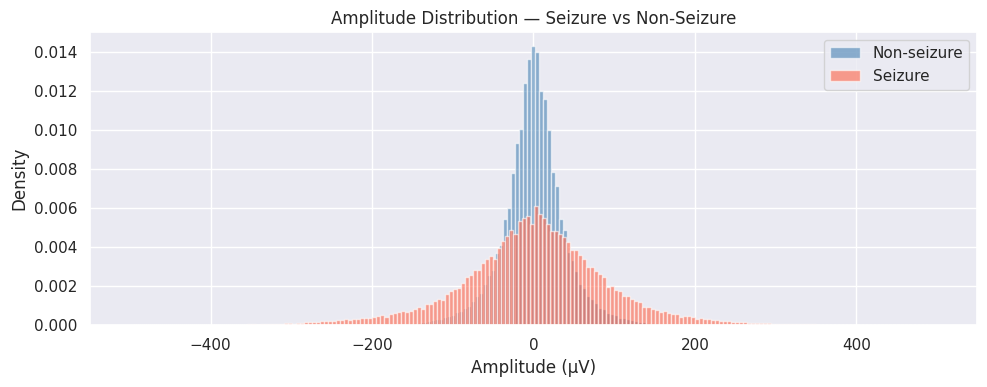

Non-seizure: mean=0.20 µV,  std=41.58 µV
Seizure    : mean=0.21 µV,  std=96.63 µV


In [10]:
# ── Amplitude distribution: seizure vs non-seizure ─────────────────────────
sz_mask   = label_array == 1
non_mask  = label_array == 0

sz_amp    = data[:, sz_mask].flatten()
non_amp   = data[:, non_mask].flatten()

# clip for readability
clip = 500
sz_amp  = sz_amp[(sz_amp > -clip) & (sz_amp < clip)]
non_amp = non_amp[(non_amp > -clip) & (non_amp < clip)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(non_amp, bins=200, alpha=0.6, color='steelblue', label='Non-seizure', density=True)
ax.hist(sz_amp,  bins=200, alpha=0.6, color='tomato',    label='Seizure',     density=True)
ax.set_xlabel('Amplitude (µV)'); ax.set_ylabel('Density')
ax.set_title('Amplitude Distribution — Seizure vs Non-Seizure')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Non-seizure: mean={non_amp.mean():.2f} µV,  std={non_amp.std():.2f} µV')
print(f'Seizure    : mean={sz_amp.mean():.2f} µV,  std={sz_amp.std():.2f} µV')

Seizure 2 has start but no end — skipping
Expected 2 seizures, parsed 1
Expected 2 seizures, parsed 1
Expected 2 seizures, parsed 1
Expected 3 seizures, parsed 1


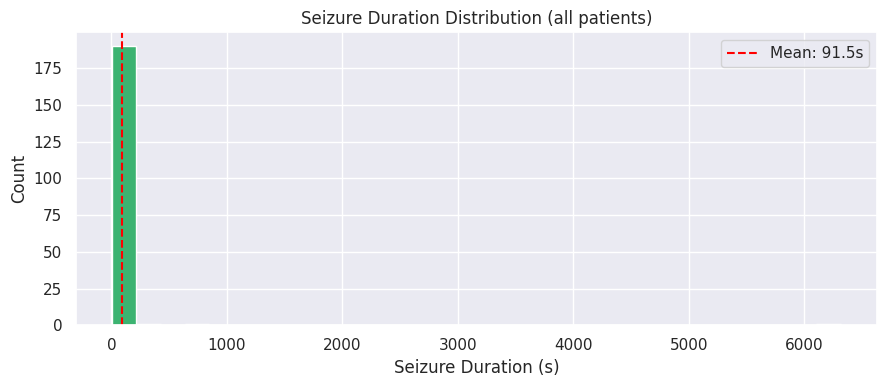

Seizures : n=193
Min      : 6.0s
Max      : 6316.0s
Mean     : 91.5s
Median   : 46.0s


In [11]:
# ── Seizure duration histogram across all patients ─────────────────────────
all_durations = []
for pdir in patient_dirs:
    ppath     = os.path.join(DATA_DIR, pdir)
    summaries = [f for f in os.listdir(ppath) if 'summary' in f.lower() and f.endswith('.txt')]
    if not summaries: continue
    ann_ = parse_summary_file(os.path.join(ppath, summaries[0]))
    for seiz_list in ann_.values():
        for s in seiz_list:
            all_durations.append(s.duration)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_durations, bins=30, color='mediumseagreen', edgecolor='white')
ax.axvline(np.mean(all_durations), color='red', linestyle='--', label=f'Mean: {np.mean(all_durations):.1f}s')
ax.set_xlabel('Seizure Duration (s)'); ax.set_ylabel('Count')
ax.set_title('Seizure Duration Distribution (all patients)')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Seizures : n={len(all_durations)}')
print(f'Min      : {min(all_durations):.1f}s')
print(f'Max      : {max(all_durations):.1f}s')
print(f'Mean     : {np.mean(all_durations):.1f}s')
print(f'Median   : {np.median(all_durations):.1f}s')

---
## 4. EDA — Frequency Analysis

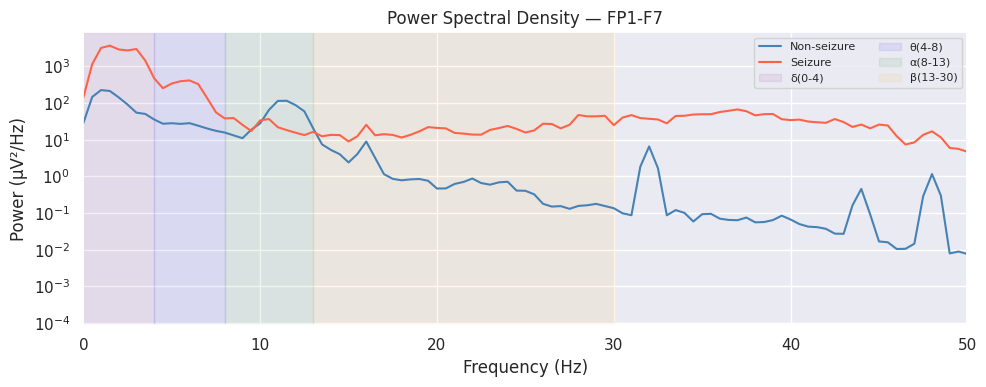

In [12]:
# ── Power Spectral Density: seizure vs non-seizure ─────────────────────────
ch_idx = 0

seg_len  = 30 * FS
sz_seg   = data[ch_idx, sz_start : sz_start + seg_len]
non_seg  = data[ch_idx, pre_start : pre_start + seg_len]

f_sz,  psd_sz  = welch(sz_seg,  fs=FS, nperseg=FS*2)
f_non, psd_non = welch(non_seg, fs=FS, nperseg=FS*2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(f_non, psd_non, color='steelblue', label='Non-seizure', lw=1.5)
ax.semilogy(f_sz,  psd_sz,  color='tomato',    label='Seizure',     lw=1.5)
ax.set_xlim(0, 50); ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Power (µV²/Hz)')
ax.set_title(f'Power Spectral Density — {ch_names[ch_idx]}')
for band, (lo, hi, c) in {'δ(0-4)':(0,4,'purple'), 'θ(4-8)':(4,8,'blue'),
                           'α(8-13)':(8,13,'green'), 'β(13-30)':(13,30,'orange')}.items():
    ax.axvspan(lo, hi, alpha=0.07, color=c, label=band)
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

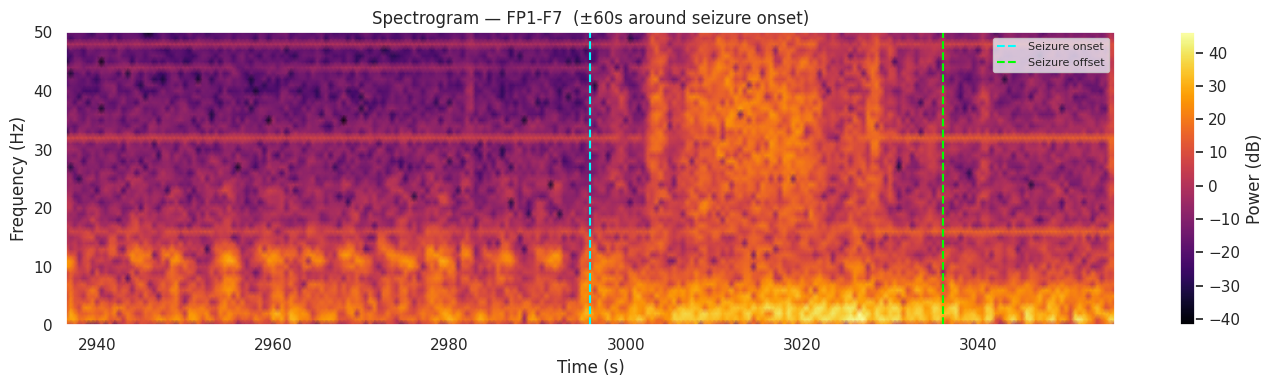

In [13]:
# ── Spectrogram centred on seizure onset ───────────────────────────────────
ch_idx  = 0
win_sec = 60
s_start = max(0, int((onset_sec - win_sec) * FS))
s_end   = min(n_samples, int((onset_sec + win_sec) * FS))
segment = data[ch_idx, s_start:s_end]

f, t_spec, Sxx = spectrogram(segment, fs=FS, nperseg=FS, noverlap=FS//2)
t_spec_abs = t_spec + (s_start / FS)

fig, ax = plt.subplots(figsize=(14, 4))
pcm = ax.pcolormesh(t_spec_abs, f[f <= 50], 10*np.log10(Sxx[f <= 50] + 1e-12),
                    shading='gouraud', cmap='inferno')
for o_, e_ in seizure_intervals:
    ax.axvline(o_, color='cyan', lw=1.5, linestyle='--', label='Seizure onset')
    ax.axvline(e_, color='lime', lw=1.5, linestyle='--', label='Seizure offset')
plt.colorbar(pcm, ax=ax, label='Power (dB)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Frequency (Hz)')
ax.set_title(f'Spectrogram — {ch_names[ch_idx]}  (±{win_sec}s around seizure onset)')
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels_[:2], loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

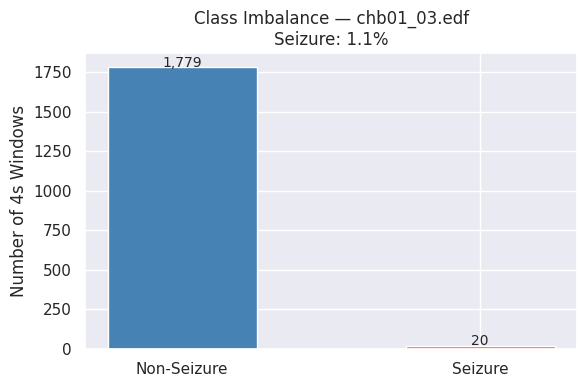

Total windows   : 1,799
Seizure windows : 20  (1.11%)
Class weight for seizure: ~89x


In [14]:
# ── Class imbalance — seizure vs non-seizure windows estimate ──────────────
total_windows  = (n_samples - WINDOW_SAMP) // STEP_SAMP + 1
seizure_samp   = label_array.sum()
sz_windows_est = int(seizure_samp / STEP_SAMP)
non_sz_est     = total_windows - sz_windows_est

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Non-Seizure', 'Seizure'], [non_sz_est, sz_windows_est],
              color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [non_sz_est, sz_windows_est]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:,}', ha='center', fontsize=10)
ax.set_ylabel('Number of 4s Windows')
ax.set_title(f'Class Imbalance — {TARGET_EDF}\nSeizure: {100*sz_windows_est/total_windows:.1f}%')
plt.tight_layout(); plt.show()

print(f'Total windows   : {total_windows:,}')
print(f'Seizure windows : {sz_windows_est:,}  ({100*sz_windows_est/total_windows:.2f}%)')
print(f'Class weight for seizure: ~{non_sz_est/max(sz_windows_est,1):.0f}x')

---
## 5. Preprocessing Pipeline

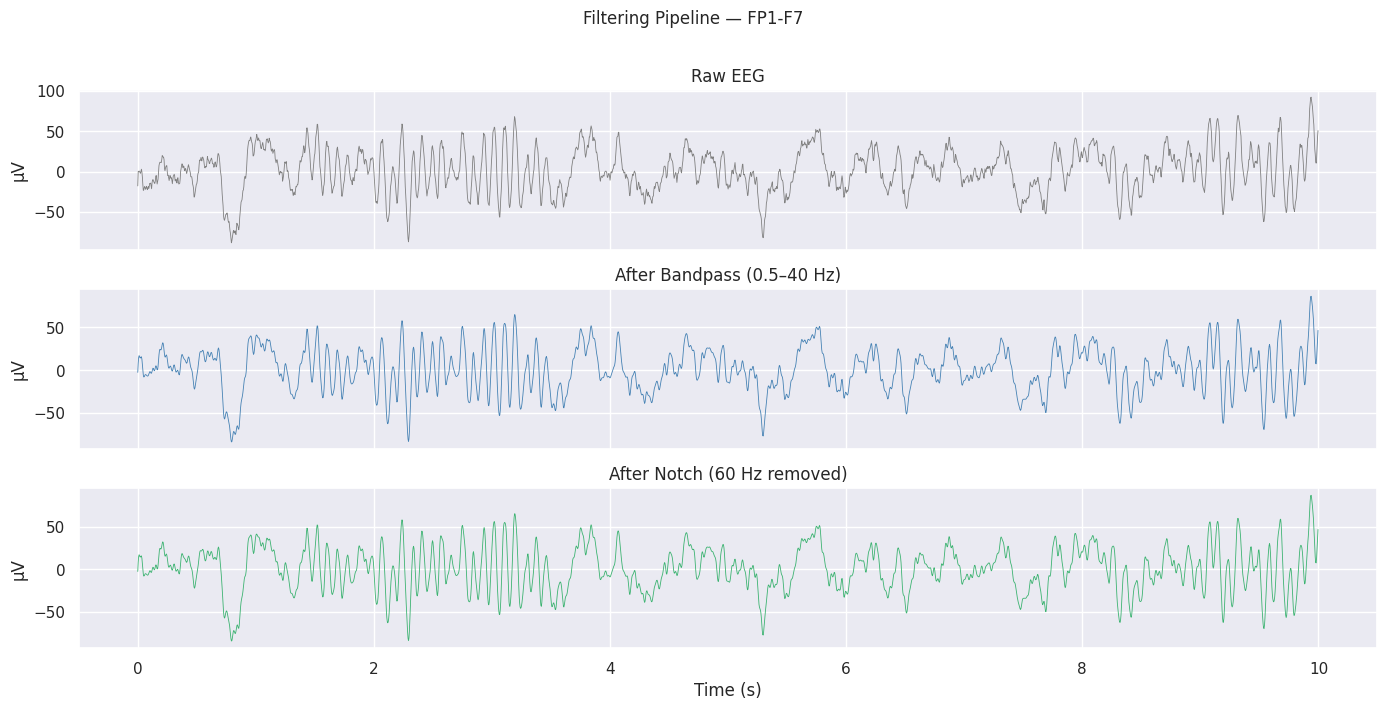

In [15]:
# ── Filtering via src.data.preprocessor ────────────────────────────────────
data_bp   = bandpass_filter(data, FS)   # 0.5–40 Hz zero-phase Butterworth
data_filt = notch_filter(data_bp, FS)   # 60 Hz powerline removal

ch_idx = 0
t_plot = np.arange(10 * FS) / FS   # first 10s

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
axes[0].plot(t_plot, data[ch_idx, :len(t_plot)],      lw=0.6, color='gray')
axes[0].set_title('Raw EEG'); axes[0].set_ylabel('µV')

axes[1].plot(t_plot, data_bp[ch_idx, :len(t_plot)],   lw=0.6, color='steelblue')
axes[1].set_title('After Bandpass (0.5–40 Hz)'); axes[1].set_ylabel('µV')

axes[2].plot(t_plot, data_filt[ch_idx, :len(t_plot)], lw=0.6, color='mediumseagreen')
axes[2].set_title('After Notch (60 Hz removed)'); axes[2].set_ylabel('µV')
axes[2].set_xlabel('Time (s)')

plt.suptitle(f'Filtering Pipeline — {ch_names[ch_idx]}', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

In [16]:
# ── Window segmentation + labeling via src.data.preprocessor ──────────────
windows, win_labels = create_windows(
    data_filt, label_array,
    window_size=WINDOW_SAMP,
    step_size=STEP_SAMP,
    seizure_threshold=0.5,
)

print(f'Windows shape  : {windows.shape}   (n_windows × channels × samples)')
print(f'Labels shape   : {win_labels.shape}')
print(f'Seizure windows: {win_labels.sum()} / {len(win_labels)}  ({100*win_labels.mean():.2f}%)')

Windows shape  : (1799, 23, 1024)   (n_windows × channels × samples)
Labels shape   : (1799,)
Seizure windows: 21 / 1799  (1.17%)


In [17]:
# ── Z-score normalization via src.data.preprocessor ───────────────────────
windows_norm = zscore_normalize(windows)

print(f'Before normalization — mean: {windows.mean():.2f},  std: {windows.std():.2f}')
print(f'After  normalization — mean: {windows_norm.mean():.4f},  std: {windows_norm.std():.4f}')

Before normalization — mean: -0.00,  std: 40.64
After  normalization — mean: -0.0000,  std: 1.0000


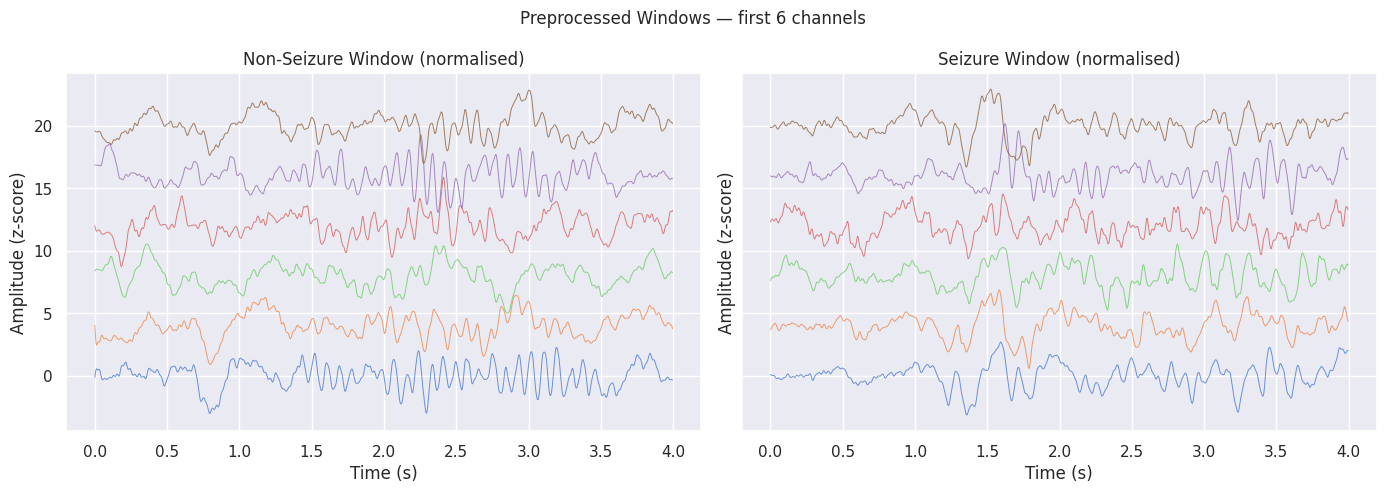

In [18]:
# ── Visualise a seizure window vs a normal window ──────────────────────────
sz_idx  = np.where(win_labels == 1)[0][0]
non_idx = np.where(win_labels == 0)[0][0]
t_win   = np.arange(WINDOW_SAMP) / FS
offset  = 4   # normalised units offset between channels

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for c in range(min(6, n_channels)):
    axes[0].plot(t_win, windows_norm[non_idx, c] + c*offset, lw=0.7, alpha=0.8)
    axes[1].plot(t_win, windows_norm[sz_idx,  c] + c*offset, lw=0.7, alpha=0.8)

axes[0].set_title('Non-Seizure Window (normalised)')
axes[1].set_title('Seizure Window (normalised)')
for ax in axes:
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (z-score)')
plt.suptitle('Preprocessed Windows — first 6 channels', fontsize=12)
plt.tight_layout(); plt.show()

In [19]:
# ── Sample table: first 5 windows ─────────────────────────────────────────
df_windows = pd.DataFrame({
    'Window':         range(5),
    'Label':          ['SEIZURE' if l else 'Normal' for l in win_labels[:5]],
    'Mean (all ch)':  [round(float(windows_norm[i].mean()), 4) for i in range(5)],
    'Std (all ch)':   [round(float(windows_norm[i].std()),  4) for i in range(5)],
    'Max amplitude':  [round(float(windows_norm[i].max()),  4) for i in range(5)],
})
print('First 5 windows after preprocessing:')
df_windows

First 5 windows after preprocessing:


,Window,Label,Mean (all ch),Std (all ch),Max amplitude
0,0,Normal,-0.0,1.0,3.8640
1,1,Normal,-0.0,1.0,4.0693
2,2,Normal,0.0,1.0,3.4222
3,3,Normal,0.0,1.0,4.1732
4,4,Normal,0.0,1.0,3.7970


---
## 6. Final Dataset Summary

---
## 6. Save Preprocessed Data to Disk

In [22]:
import time, yaml
from src.data.dataset import build_split_dataset

# ── All config loaded here so this cell is self-contained ─────────────────
PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

TARGET_CHANNELS = cfg['data']['channels']   # 23 bipolar channels — fixes 23/24 mismatch

SPLITS = {
    'train': list(range(1, 19)),
    'val':   [19, 20, 21],
    'test':  [22, 23, 24],
}

print(f'Target channels : {len(TARGET_CHANNELS)}')
print(f'Saving to       : {os.path.abspath(PROCESSED_DIR)}\n')

Target channels : 23
Saving to       : /home/stu15/s0/cm7513/NeuroScribe-EEG-Seizure-Detection-with-Evidence-Grounded-Clinical-Reporting/data/processed



In [23]:
# ── Build + save each split ────────────────────────────────────────────────
split_stats = {}

for split_name, patient_ids in SPLITS.items():
    print(f'[{split_name}] patients: {[f"chb{p:02d}" for p in patient_ids]}')
    t0 = time.time()

    ds = build_split_dataset(
        raw_dir=DATA_DIR,
        patient_ids=patient_ids,
        split_name=split_name,
        target_channels=TARGET_CHANNELS,
        window_size_sec=WINDOW_SEC,
        overlap=OVERLAP,
        seizure_threshold=0.5,
        bandpass_low=0.5,
        bandpass_high=40.0,
        notch_freq=60.0,
        sample_rate=FS,
        processed_dir=PROCESSED_DIR,
        use_cache=True,
    )

    elapsed   = time.time() - t0
    save_path = os.path.join(PROCESSED_DIR, f'{split_name}.npz')
    size_mb   = os.path.getsize(save_path) / 1e6 if os.path.exists(save_path) else 0

    split_stats[split_name] = {
        'windows':  len(ds),
        'seizure':  ds.n_seizure,
        'fraction': round(ds.seizure_fraction, 4),
        'size_mb':  round(size_mb, 1),
    }
    print(f'  → {len(ds):,} windows  |  {ds.n_seizure:,} seizure '
          f'({100*ds.seizure_fraction:.2f}%)  |  {size_mb:.0f} MB  |  {elapsed:.0f}s\n')

print('Done.')

[train] patients: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb17', 'chb18']


Seizure 2 has start but no end — skipping
Expected 2 seizures, parsed 1
chb12_27.edf: channels not found: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
No target channels found in ../data/chb-mit/chb12/chb12_27.edf. Using all available.
chb12_28.edf: channels not found: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
No target channels found in ../data/chb-mit/chb12/chb12_28.edf. Using all available.
chb12_29.edf: channels not found: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', '

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 23 and the array at index 343 has size 29

In [ ]:

# ── Final summary table ────────────────────────────────────────────────────
print(f'\n{"="*58}')
print(f'{"SAVED FILES":^58}')
print(f'{"="*58}')
print(f'  Location: {os.path.abspath(PROCESSED_DIR)}')
print()
print(f'  {"Split":<8} {"File":<18} {"Windows":>10} {"Seizure":>10} {"Fraction":>10} {"Size":>8}')
print(f'  {"-"*56}')
for split, s in split_stats.items():
    fname = f'{split}.npz'
    print(f'  {split:<8} {fname:<18} {s["windows"]:>10,} {s["seizure"]:>10,} '
          f'{s["fraction"]:>10.2%} {s["size_mb"]:>6.0f} MB')

print(f'\n  Arrays inside each .npz:')
print(f'    windows     → shape (N, channels, 1024)  float32')
print(f'    labels      → shape (N,)                 int8  (0=normal, 1=seizure)')
print(f'    patient_ids → shape (N,)                 int32')
print(f'\n  Load with:')
print(f'    d = np.load("data/processed/train.npz")')
print(f'    X, y = d["windows"], d["labels"]')


In [ ]:
# ── Summary table for all patients on disk ────────────────────────────────
summary_rows = []
for pdir in patient_dirs:
    ppath = os.path.join(DATA_DIR, pdir)
    pid   = int(pdir.replace('chb', ''))
    try:
        recs = build_patient_manifest(ppath, patient_id=pid)
    except Exception:
        continue

    edfs_on_disk = [r for r in recs if os.path.exists(r.edf_path)]
    if not edfs_on_disk: continue

    stats    = dataset_stats(recs, sample_rate=FS)
    total_sz = stats['seizure_duration_mean_s'] * stats['total_seizure_events']
    est_windows    = len(edfs_on_disk) * 3600 // STEP_SAMP
    est_sz_windows = int(total_sz * FS / STEP_SAMP)

    summary_rows.append({
        'Patient':           pdir,
        'EDFs on disk':      len(edfs_on_disk),
        'Seizure events':    stats['total_seizure_events'],
        'Seizure EDFs':      stats['recordings_with_seizure'],
        'Total seizure (s)': round(total_sz, 1),
        'Est. sz windows':   est_sz_windows,
        'Est. class weight': round(est_windows / max(est_sz_windows, 1), 1),
    })

df_final = pd.DataFrame(summary_rows)
print('Dataset ready for model training:')
df_final

In [ ]:
print('='*50)
print('PREPROCESSING PIPELINE VERIFIED')
print('='*50)
print(f'  Input      : raw EDF  shape {data.shape}  (µV)')
print(f'  Filtered   : bandpass 0.5–40Hz + notch 60Hz  (src.data.preprocessor)')
print(f'  Windows    : {windows_norm.shape}  (n × channels × {WINDOW_SAMP} samples)')
print(f'  Labels     : {win_labels.shape}  — {win_labels.sum()} seizure / {(win_labels==0).sum()} normal')
print(f'  Normalised : mean={windows_norm.mean():.4f},  std={windows_norm.std():.4f}')
print(f'  Ready for CNN+GRU baseline training.')